In [2]:
import matplotlib.pyplot as plt
import numpy as np


def load_signal(filepath):
  return np.fromfile(filepath, dtype='float64')


dir = 'simulations/lit-system-open-loop'

time = load_signal(f'{dir}/time.bin')
x1 = load_signal(f'{dir}/x1.bin')
x2 = load_signal(f'{dir}/x2.bin')

=== Resultados para: Sistema Suave ===
Erro máximo absoluto em x1: 1.74e-12
Erro máximo absoluto em x2: 1.53e-12



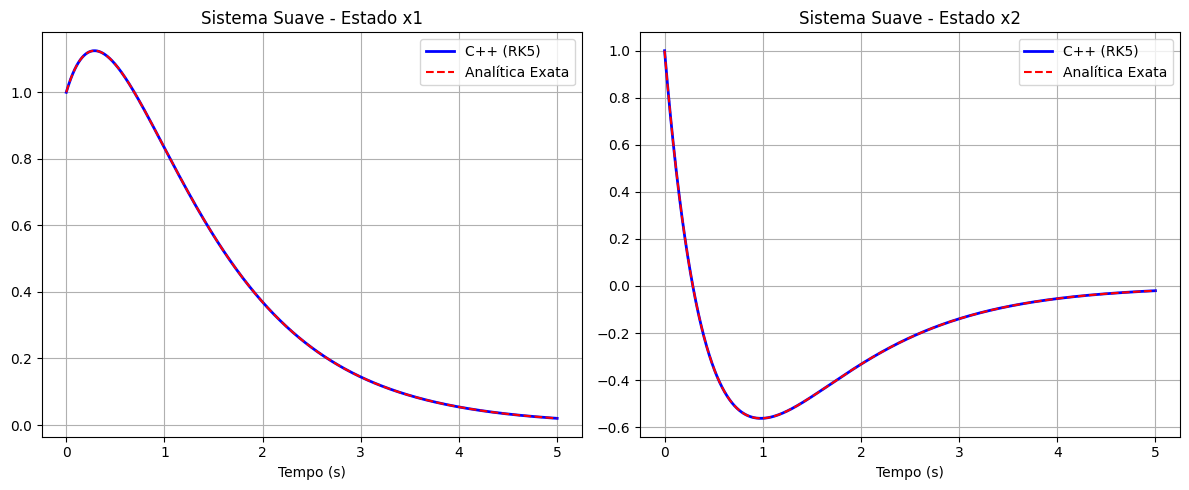

=== Resultados para: Sistema Stiff (Não Suave) ===
Erro máximo absoluto em x1: 7.02e-15
Erro máximo absoluto em x2: 1.04e-14



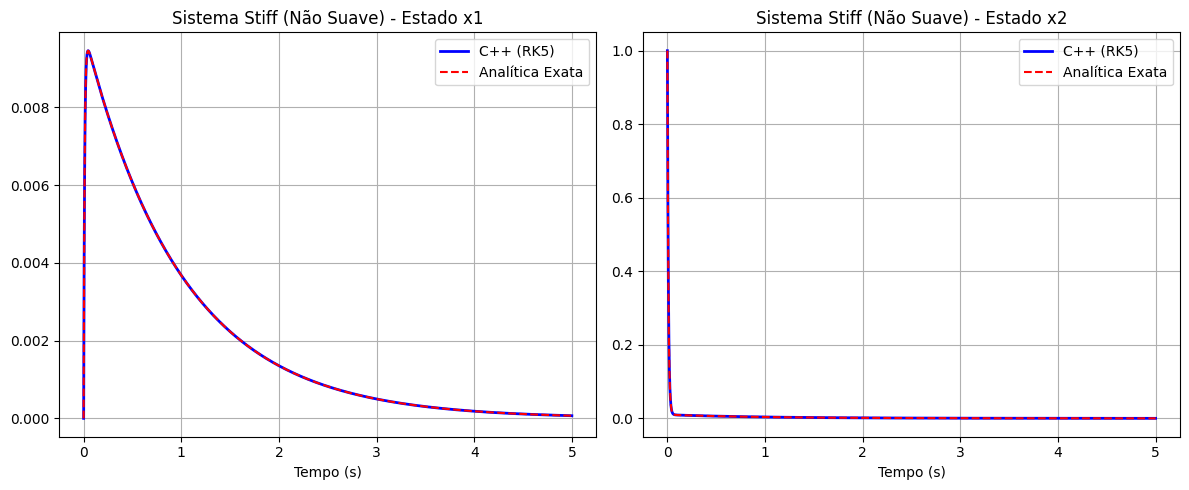

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_test(system_name, x1_cpp_path, x2_cpp_path, time_path, analytical_func):
  # 1. Carrega os dados salvos pela simulação em C++
  time = np.fromfile(time_path, dtype='float64')
  x1_cpp = np.fromfile(x1_cpp_path, dtype='float64')
  x2_cpp = np.fromfile(x2_cpp_path, dtype='float64')

  # 2. Calcula a solução analítica exata nos mesmos instantes de tempo
  x1_exact, x2_exact = analytical_func(time)

  # 3. Cálculo do Erro Absoluto Máximo
  err_x1 = np.max(np.abs(x1_cpp - x1_exact))
  err_x2 = np.max(np.abs(x2_cpp - x2_exact))

  print(f"=== Resultados para: {system_name} ===")
  print(f"Erro máximo absoluto em x1: {err_x1:.2e}")
  print(f"Erro máximo absoluto em x2: {err_x2:.2e}\n")

  # 4. Plotagem comparativa
  plt.figure(figsize=(12, 5))

  plt.subplot(1, 2, 1)
  plt.plot(time, x1_cpp, label='C++ (RK5)', color='blue', linewidth=2)
  plt.plot(time, x1_exact, label='Analítica Exata',
           color='red', linestyle='--', linewidth=1.5)
  plt.title(f'{system_name} - Estado x1')
  plt.xlabel('Tempo (s)')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(time, x2_cpp, label='C++ (RK5)', color='blue', linewidth=2)
  plt.plot(time, x2_exact, label='Analítica Exata',
           color='red', linestyle='--', linewidth=1.5)
  plt.title(f'{system_name} - Estado x2')
  plt.xlabel('Tempo (s)')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

# --- Teste 1: Sistema Suave ---


def analytical_smooth(t):
  x1 = 3.0 * np.exp(-t) - 2.0 * np.exp(-2.0 * t)
  x2 = -3.0 * np.exp(-t) + 4.0 * np.exp(-2.0 * t)
  return x1, x2


evaluate_test(
    "Sistema Suave",
    dir + '-smooth/x1.bin',
    dir + '-smooth/x2.bin',
    dir + '-smooth/time.bin',
    analytical_smooth
)

# --- Teste 2: Sistema Não Tão Suave (Stiff) ---


def analytical_stiff(t):
  x1 = 0.01 * np.exp(-t) - 0.01 * np.exp(-101.0 * t)
  x2 = 0.01 * np.exp(-t) + 0.99 * np.exp(-101.0 * t)
  return x1, x2


evaluate_test(
    "Sistema Stiff (Não Suave)",
    dir + '-stiff/x1.bin',
    dir + '-stiff/x2.bin',
    dir + '-stiff/time.bin',
    analytical_stiff
)